# Taller 1: Econometría

- **Profesor:** Francisco Alfaro Medina
- **Ayudantes:** Krischnna Cortez y Karen Rojas


### Instrucciones

- Dispone de **60 minutos** para completar los **100 puntos** del taller.
- Cuide la presentación y redacción de sus respuestas.
- Puede utilizar su computador y los apuntes de clase y ayudantía.
- Debe entregar un archivo **PDF** y un **R script** (extensión `.R`).

> ⚠️ **Importante para Colab:** Este notebook usa un kernel de R. Si abre este archivo en Google Colab, seleccione **Runtime → Change runtime type → R** antes de ejecutar cualquier celda.

---
# Sección 1: Datos Aleatorios *(30 puntos)*

En esta sección trabajaremos con un dataset **simulado** de 50 alumnos de la USM. El dataset contiene las siguientes variables:

| Variable | Descripción |
|---|---|
| `hrs_sueno` | Horas de sueño promedio en el último mes |
| `profesor_part` | Si recibió ayuda de profesor particular (0/1) |
| `media_sem_pasado` | Promedio de notas del semestre anterior |
| `tiempo_est` | Horas de estudio dedicadas |
| `asistencia` | Porcentaje de asistencia a clases |
| `nivel_socioec` | Nivel socioeconómico (1 al 5) |
| `notas` | **Variable dependiente** — nota del alumno |

## Pregunta 1.1 — Generar el dataset *(6 pts.)*

Antes de ejecutar el código, **cambie la semilla** según la primera letra de su apellido:

| A–E | F–J | K–O | P–T | U–Z |
|:---:|:---:|:---:|:---:|:---:|
| 123 | 456 | 789 | 101112 | 131415 |

Reemplace el valor en `set.seed(...)` antes de continuar.

In [3]:
# -------------------------------------------------------
# Pregunta 1.1: Generar el dataframe "datos"
# Cambie la semilla según la primera letra de su apellido
# A-E: 123 | F-J: 456 | K-O: 789 | P-T: 101112 | U-Z: 131415
# -------------------------------------------------------

set.seed(123)  # <-- CAMBIE ESTE VALOR SEGÚN SU APELLIDO

datos <- data.frame(
  hrs_sueno        = round(runif(50, min = 5,  max = 10),  1),
  profesor_part    = sample(c(0, 1), 50, replace = TRUE),
  media_sem_pasado = round(runif(50, min = 60, max = 100), 1),
  tiempo_est       = round(runif(50, min = 1,  max = 8),   1),
  asistencia       = round(runif(50, min = 60, max = 100), 1),
  nivel_socioec    = sample(1:5, 50, replace = TRUE)
)

# Calcular notas con ponderaciones definidas
datos$notas <- 30 +
  datos$hrs_sueno        * 1.5  +
  datos$profesor_part    * 3    +
  datos$media_sem_pasado * 0.2  +
  datos$tiempo_est       * 2    +
  datos$asistencia       * 0.15 +
  datos$nivel_socioec    * 2    +
  rnorm(50, mean = 0, sd = 5)

# Asegurar rango entre 20 y 100
datos$notas <- pmax(pmin(datos$notas, 100), 20)

# Vista rápida del dataset
cat("Dimensiones del dataset:", nrow(datos), "filas x", ncol(datos), "columnas\n")
head(datos)

Dimensiones del dataset: 50 filas x 7 columnas


,hrs_sueno,profesor_part,media_sem_pasado,tiempo_est,asistencia,nivel_socioec,notas
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,6.4,1,84.0,6.9,69.5,1,90.88856
2,8.9,0,73.3,4.5,98.5,2,80.53911
3,7.0,0,79.5,3.7,84.1,5,80.11422
4,9.4,0,98.2,2.7,80.6,5,100.00000
5,9.7,0,79.3,1.8,76.1,1,75.34071
6,5.2,1,95.6,3.7,95.2,2,87.09114


## Pregunta 1.2 — Redondear notas *(2 pts.)*

Redondee la variable `notas` a **1 decimal**.

In [4]:
# Pregunta 1.2: Redondear notas a 1 decimal
datos$notas <- round(datos$notas, 1)
head(datos$notas)

[1]  90.9  80.5  80.1 100.0  75.3  87.1

1. Al redondear las notas a 1 decimal da los siguientes resultados: 90.9, 80.5, 80.1, 100, 7.3 y 87.1

## Pregunta 1.3 — Estimadores β via álgebra matricial *(8 pts.)*

Calcule los estimadores MCO **manualmente**, usando la fórmula matricial:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

**Sin usar** la función `lm()` de R.

In [5]:
# Pregunta 1.3: Estimadores beta via álgebra matricial (sin lm)
X <- as.matrix(cbind(1, datos[, 1:6]))
y <- as.matrix(datos$notas)

beta_hat <- solve(t(X) %*% X) %*% t(X) %*% y
print(beta_hat)

                       [,1]
1                33.3690724
hrs_sueno         1.1951165
profesor_part     4.9123586
media_sem_pasado  0.2019283
tiempo_est        1.0010140
asistencia        0.1803130
nivel_socioec     2.0867480


## Pregunta 1.4 — Modelo con `lm()` e interpretación *(8 pts.)*

Genere el modelo de regresión múltiple usando la función `lm()` y obtenga el resumen con `summary()`.  
Luego, **interprete cada coeficiente** en el espacio indicado.

> 💡 **Tip:** Los β de `lm()` deben coincidir con los calculados manualmente en la pregunta anterior.

In [6]:
# Pregunta 1.4: Modelo con lm() y summary
modelo_multiple <- lm(notas ~ hrs_sueno + profesor_part + media_sem_pasado +
                       tiempo_est + asistencia + nivel_socioec, data = datos)
summary(modelo_multiple)


Call:
lm(formula = notas ~ hrs_sueno + profesor_part + media_sem_pasado + 
    tiempo_est + asistencia + nivel_socioec, data = datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.5651 -3.4436  0.2434  2.7986  8.7644 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)      33.36907    8.50166   3.925 0.000308 ***
hrs_sueno         1.19512    0.44030   2.714 0.009519 ** 
profesor_part     4.91236    1.37464   3.574 0.000884 ***
media_sem_pasado  0.20193    0.05667   3.563 0.000912 ***
tiempo_est        1.00101    0.41041   2.439 0.018926 *  
asistencia        0.18031    0.06077   2.967 0.004895 ** 
nivel_socioec     2.08675    0.43137   4.837 1.72e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.478 on 43 degrees of freedom
Multiple R-squared:  0.6161,	Adjusted R-squared:  0.5626 
F-statistic:  11.5 on 6 and 43 DF,  p-value: 1.217e-07


## Pregunta 1.5 — Relación entre betas y ponderaciones del código *(6 pts.)*

Analice la relación entre los coeficientes estimados (β̂) y las ponderaciones reales usadas en el código del Anexo para generar las notas.



In [ ]:
# Pregunta 1.5: Comparación entre betas estimados y ponderaciones reales


Los coeficientes beta obtenidos a través del modelo RLM funcionan como estimaciones de las ponderaciones reales definidas en el código del Anexo, pero, no coinciden exactamente con las ponderaciones reales, ya que el modelo incorpora un término de error aleatorio. Aun así, el MCO permite aproximar correctamente los valores originales, lo que evidencia que los estimadores son insesgado


# Sección 2: Wooldridge *(70 puntos)*

Para esta sección utilizaremos el paquete `wooldridge`, que contiene bases de datos clásicas de econometría.

In [ ]:
# Instalar y cargar el paquete wooldridge (solo necesario la primera vez en Colab)
if (!require(wooldridge)) install.packages("wooldridge")
library(wooldridge)

---
## 2A. Base `wage1` *(30 puntos)*

El modelo de regresión poblacional a estimar es:

$$wage = \beta_0 + \beta_1\, educ + \beta_2\, exper + \beta_3\, tenure + u$$

Donde:
- `wage` = salario por hora (USD)
- `educ` = años de escolaridad
- `exper` = años de experiencia laboral
- `tenure` = años en el trabajo actual

In [9]:
# Cargar y limpiar la base wage1
install.packages("wooldridge")
library(wooldridge)
data("wage1")
wage1 <- na.omit(wage1)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



### Pregunta 2A.1 — Estimadores MCO e interpretación *(8 pts.)*

Estime el modelo completo e interprete los resultados.

In [10]:
# Pregunta 2A.1: Modelo de regresión múltiple con wage1
modelo_wage_total <- lm(wage ~ educ + exper + tenure, data = wage1)
summary(modelo_wage_total)


Call:
lm(formula = wage ~ educ + exper + tenure, data = wage1)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.6068 -1.7747 -0.6279  1.1969 14.6536 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.87273    0.72896  -3.941 9.22e-05 ***
educ         0.59897    0.05128  11.679  < 2e-16 ***
exper        0.02234    0.01206   1.853   0.0645 .  
tenure       0.16927    0.02164   7.820 2.93e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.084 on 522 degrees of freedom
Multiple R-squared:  0.3064,	Adjusted R-squared:  0.3024 
F-statistic: 76.87 on 3 and 522 DF,  p-value: < 2.2e-16


educ: Por cada año mas de escolaridad, el salario por hora aumenta en promedio 0.5989 dólares, manteniendo todo lo demas constante.
exper: Un año extra de experiencia laboral incrementa el salario en 0.022 dólares, por el concepto de ceteris paribus.
tenure: Por cada año adicional en el trabajo actual, el salario sube 0.1692 dólares
Estas aproximaciones son viables ya que tienen un 1, 10 y 5% de confiaza.

### Pregunta 2A.2 — ¿Los signos son los esperados? *(10 pts.)*

Antes de ver los resultados, reflexione: ¿qué signo debería tener cada coeficiente económicamente?

In [ ]:
# Pregunta 2A.2: Revisar signos de los coeficientes

TODOS los signos son EXACTAMENTE como esperábamos por teoría económica:

* POSITIVOS para educ/exper/tenure → más capital humano = más salario • Intercepto NEGATIVO → salario base sin cualificación es bajo
* Todos * significativos → no es azar, son relaciones REALES


### Pregunta 2A.3 — Comparar R² y R² ajustado *(12 pts.)*

Estime un segundo modelo usando solo `educ` y `tenure`, y compare el ajuste con el modelo completo.

In [11]:
# Pregunta 2A.3: Modelo reducido (sin exper)
modelo1 <- lm(wage ~ educ + exper + tenure, data = wage1)
modelo2 <- lm(wage ~ educ + tenure, data = wage1)
rbind(
  "Completo" = c(R2 = summary(modelo1)$r.squared,
                 R2_ajustado = summary(modelo1)$adj.r.squared),
  "Reducido" = c(R2 = summary(modelo2)$r.squared,
                 R2_ajustado = summary(modelo2)$adj.r.squared)
)

,R2,R2_ajustado
Completo,0.3064224,0.3024364
Reducido,0.3018610,0.2991912


$R^2$: El $R^2$ del modelo completo siempre será igual o mayor al del modelo reducido, porque el $R^2$ nunca baja al agregar variables.

$R^2$ ajustado: al bajar el $R^2$  ajustado quiere decir que la experencia es una variable importante para describir el salario por lo que esta no debio ser eliminada.

---
## 2B. Base `attend` *(40 puntos)*

En esta sección analizamos los determinantes del rendimiento en el examen final de un curso universitario.

### Pregunta 2B.1 — Cargar la base `attend` *(4 pts.)*

In [12]:
# Pregunta 2B.1: Cargar base attend
data("attend")
attend <- na.omit(attend)
head(attend)
dim(attend)

,attend,termGPA,priGPA,ACT,final,atndrte,hwrte,frosh,soph,missed,stndfnl
,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>
1,27,3.19,2.64,23,28,84.375,100.0,0,1,5,0.47268906
2,22,2.73,3.52,25,26,68.750,87.5,0,0,10,0.05252101
3,30,3.00,2.46,24,30,93.750,87.5,0,0,2,0.89285713
4,31,2.04,2.61,20,27,96.875,100.0,0,1,1,0.26260504
5,32,3.68,3.32,23,34,100.000,100.0,0,1,0,1.73319328
6,29,3.23,2.93,26,25,90.625,100.0,0,1,3,-0.15756303


[1] 674  11

### Pregunta 2B.2 — Selección de variables *(4 pts.)*

Subseleccione las siguientes variables:

| Variable | Descripción |
|---|---|
| `attend` | Clases asistidas de un total de 32 |
| `termGPA` | Promedio de notas durante el período |
| `priGPA` | Promedio acumulado antes del período |
| `ACT` | Puntaje en el examen ACT |
| `final` | **Variable dependiente** — puntaje del examen final |
| `hwrte` | Porcentaje de tareas entregadas |
| `frosh` | =1 si es estudiante de primer año |
| `soph` | =1 si es estudiante de segundo año |

In [14]:
# Pregunta 2B.2: Subselección de variables
datos_attend <- attend[, c("attend", "termGPA", "priGPA", "ACT",
                          "final", "hwrte", "frosh", "soph")]


head(datos_attend)
dim(datos_attend)

,attend,termGPA,priGPA,ACT,final,hwrte,frosh,soph
,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<int>
1,27,3.19,2.64,23,28,100.0,0,1
2,22,2.73,3.52,25,26,87.5,0,0
3,30,3.00,2.46,24,30,87.5,0,0
4,31,2.04,2.61,20,27,100.0,0,1
5,32,3.68,3.32,23,34,100.0,0,1
6,29,3.23,2.93,26,25,100.0,0,1


[1] 674   8

### Pregunta 2B.3 — Modelo de regresión múltiple completo *(10 pts.)*

Estime un modelo donde la variable dependiente es `final` y las independientes son todas las demás variables del subconjunto.

In [15]:
# Pregunta 2B.3: Modelo completo con attend_new
summary(datos_attend)

     attend         termGPA          priGPA           ACT       
 Min.   : 2.00   Min.   :0.000   Min.   :0.857   Min.   :13.00  
 1st Qu.:24.00   1st Qu.:2.150   1st Qu.:2.200   1st Qu.:20.00  
 Median :28.00   Median :2.680   Median :2.560   Median :22.00  
 Mean   :26.28   Mean   :2.614   Mean   :2.592   Mean   :22.48  
 3rd Qu.:30.00   3rd Qu.:3.120   3rd Qu.:2.950   3rd Qu.:25.00  
 Max.   :32.00   Max.   :4.000   Max.   :3.930   Max.   :32.00  
     final           hwrte            frosh           soph       
 Min.   :10.00   Min.   : 12.50   Min.   :0.00   Min.   :0.0000  
 1st Qu.:22.00   1st Qu.: 87.50   1st Qu.:0.00   1st Qu.:0.0000  
 Median :26.00   Median :100.00   Median :0.00   Median :1.0000  
 Mean   :25.89   Mean   : 87.91   Mean   :0.23   Mean   :0.5801  
 3rd Qu.:29.00   3rd Qu.:100.00   3rd Qu.:0.00   3rd Qu.:1.0000  
 Max.   :39.00   Max.   :100.00   Max.   :1.00   Max.   :1.0000  

### Pregunta 2B.4 — Bondad de ajuste *(6 pts.)*

Interprete el **R²** y el **R² ajustado** del modelo anterior.

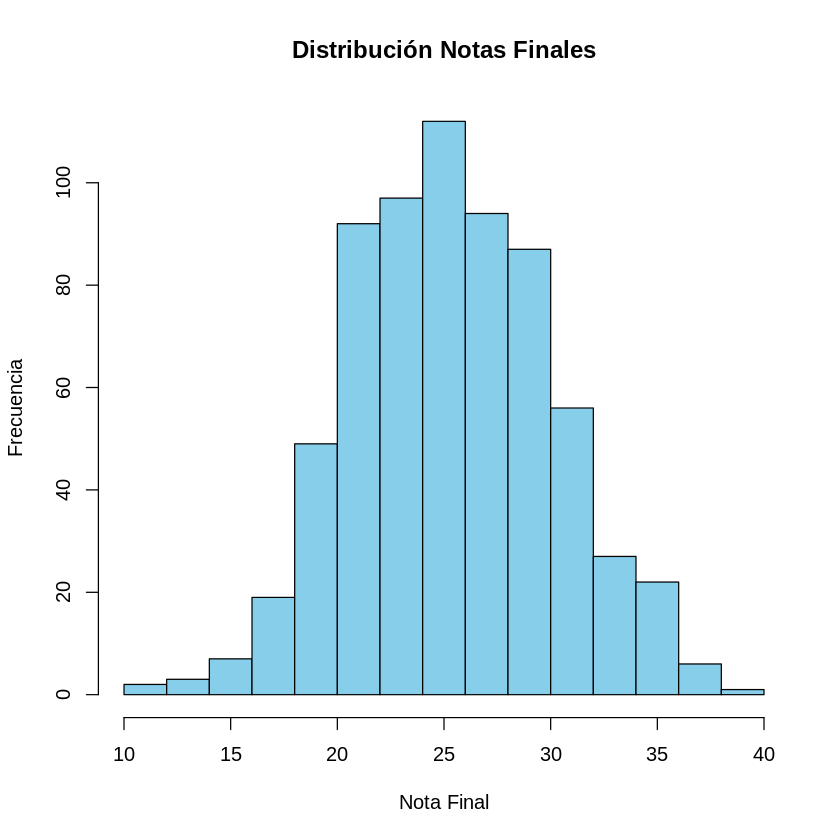

In [16]:
# Pregunta 2B.4: Extraer métricas de bondad de ajuste
hist(datos_attend$final,
     main = "Distribución Notas Finales",
     xlab = "Nota Final",
     ylab = "Frecuencia",
     col = "skyblue",
     breaks = 20)

### Pregunta 2B.5 — Modelo reducido (excluir variables no significativas) *(10 pts.)*

Genere un nuevo modelo excluyendo las variables con **p-value > 0.05** en el modelo anterior.

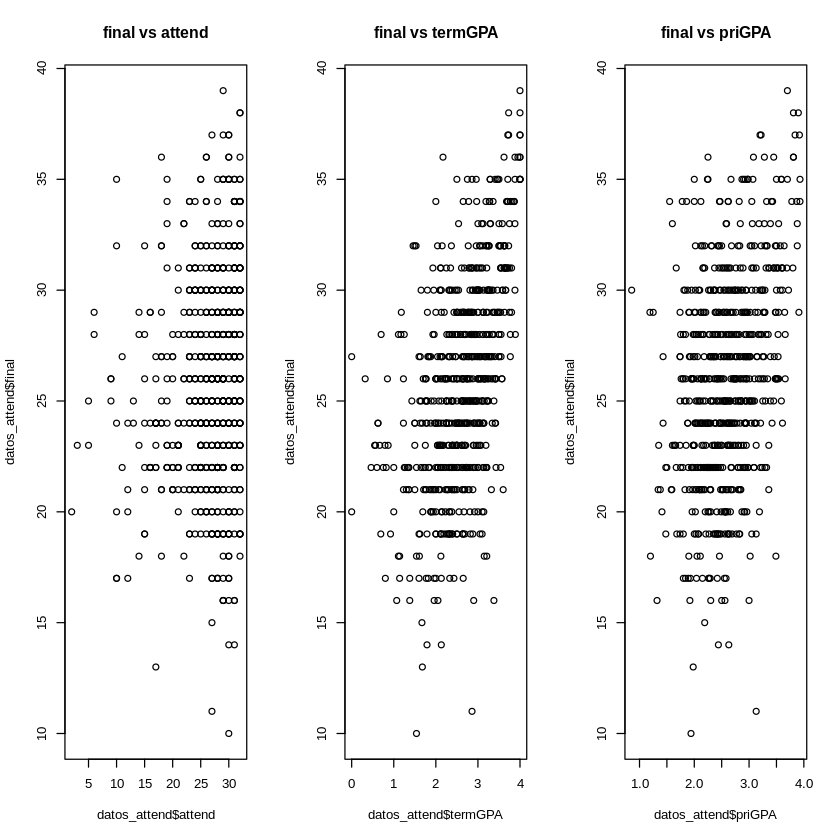

In [18]:
# Identificar variables significativas (p-value <= 0.05)
#PREGUNTA 2b.5 DEL ENUNCIADO PDF
par(mfrow = c(1, 3))

plot(datos_attend$attend, datos_attend$final,
     main = "final vs attend")

plot(datos_attend$termGPA, datos_attend$final,
     main = "final vs termGPA")

plot(datos_attend$priGPA, datos_attend$final,
     main = "final vs priGPA")

In [ ]:
Genere diagramas de dispersión de final respecto a attend, termGPA y priGPA en un
panel par(mfrow=c(1,3))

### Pregunta 2B.6 — Comparación de modelos *(6 pts.)*

Compare el modelo completo y el modelo reducido en términos de **R² ajustado**.

In [ ]:
# Pregunta 2B.6: Comparación final de modelos